In [2]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Generate signal: 2, 4, 8, 16, 32 Hz + white noise
# Sampling frequency
fs = 1000   # samples per second

# Duration
duration = 60   # 60 seconds = 1 minute

# Time vector
t = np.arange(0, duration, 1/fs)

# Frequencies to combine
frequencies = [2, 4, 8, 16, 32]

# Create signal by adding sine waves
signal_clean = np.zeros_like(t)

for f in frequencies:
    signal_clean += np.sin(2 * np.pi * f * t)

# Add white Gaussian noise
noise = np.random.normal(0, 1, len(t))

signal_noisy = signal_clean + noise

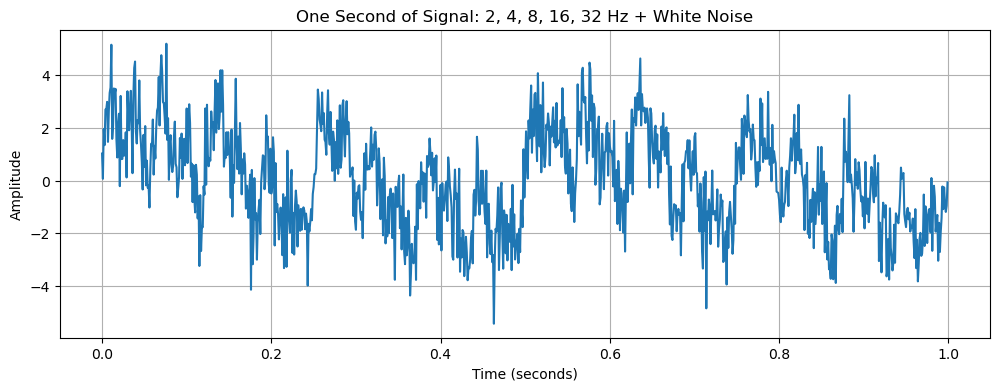

In [5]:
 #one second of the signal
one_second = fs * 1

plt.figure(figsize=(12, 4))
plt.plot(t[:one_second], signal_noisy[:one_second])
plt.title("One Second of Signal: 2, 4, 8, 16, 32 Hz + White Noise")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

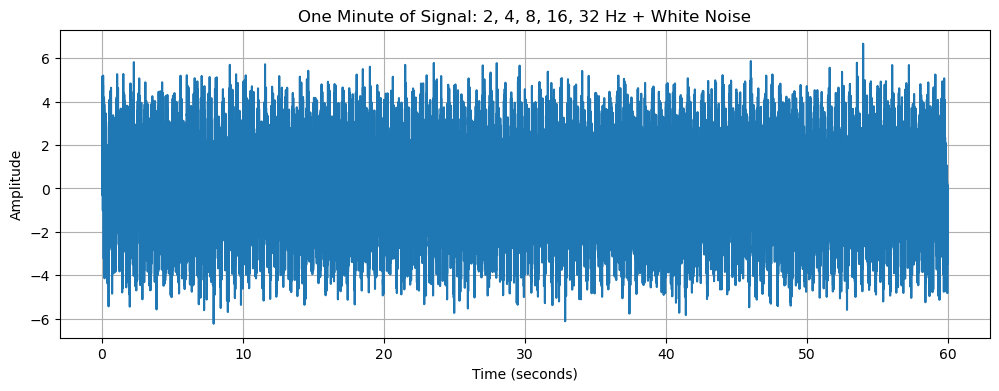

In [6]:
#one minute of the signal
plt.figure(figsize=(12, 4))
plt.plot(t, signal_noisy)
plt.title("One Minute of Signal: 2, 4, 8, 16, 32 Hz + White Noise")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

##Stationary or non-stationary? Linear or non-linear?
## Stationarity and Linearity
The generated signal is stationary because the same frequency components (2, 4, 8, 16, and 32 Hz) are present throughout the entire 60-second recording. The statistical properties of the signal are expected to remain relatively constant over time, apart from random white noise.

The signal is linear because it was created by adding sine waves together. The combination is a linear superposition of multiple sinusoidal components plus additive white noise. No nonlinear transformation, such as squaring, multiplication between frequencies, or exponential transformation, was applied.

In [8]:
#Compute FFT and power spectrum
# Number of samples
N = len(signal_noisy)

# FFT
fft_values = np.fft.fft(signal_noisy)

# Frequency axis
freq_axis = np.fft.fftfreq(N, d=1/fs)

# Keep only positive frequencies
positive_freqs = freq_axis[:N//2]
positive_fft = fft_values[:N//2]

# Power spectrum
power = np.abs(positive_fft)**2 / N

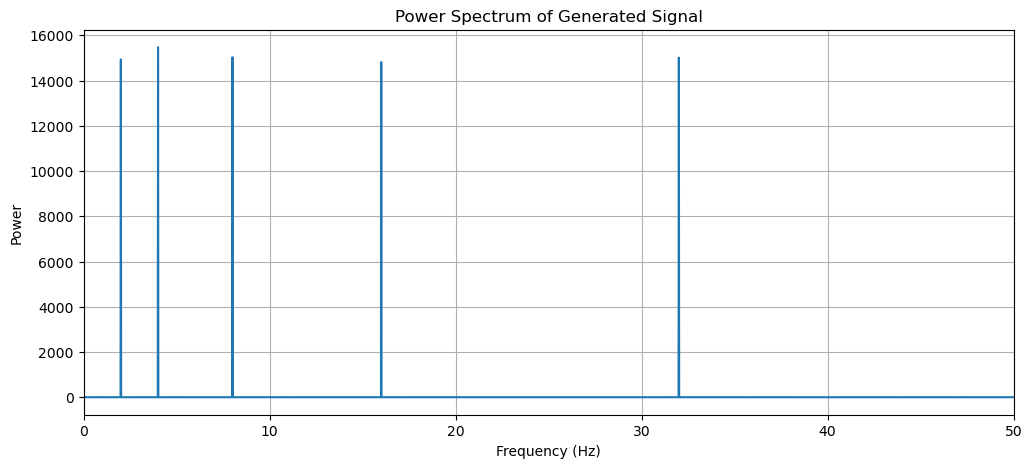

In [9]:
#Plot power spectrum
plt.figure(figsize=(12, 5))
plt.plot(positive_freqs, power)
plt.title("Power Spectrum of Generated Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.xlim(0, 50)
plt.grid(True)
plt.show()

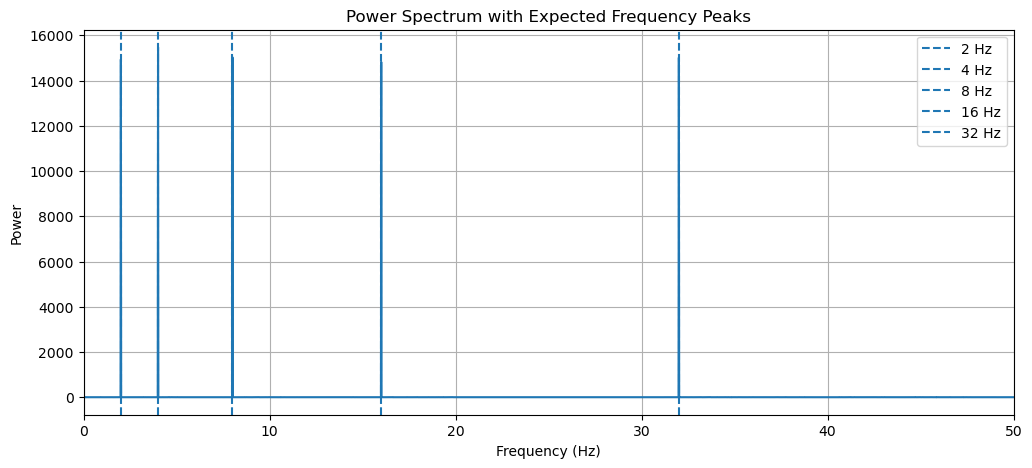

In [10]:
#expected frequencies
plt.figure(figsize=(12, 5))
plt.plot(positive_freqs, power)

for f in frequencies:
    plt.axvline(f, linestyle="--", label=f"{f} Hz")

plt.title("Power Spectrum with Expected Frequency Peaks")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.xlim(0, 50)
plt.legend()
plt.grid(True)
plt.show()

I see peaks around 2, 4, 8, 16, and 32 Hz.